Model Accuracy: 0.6761904761904762


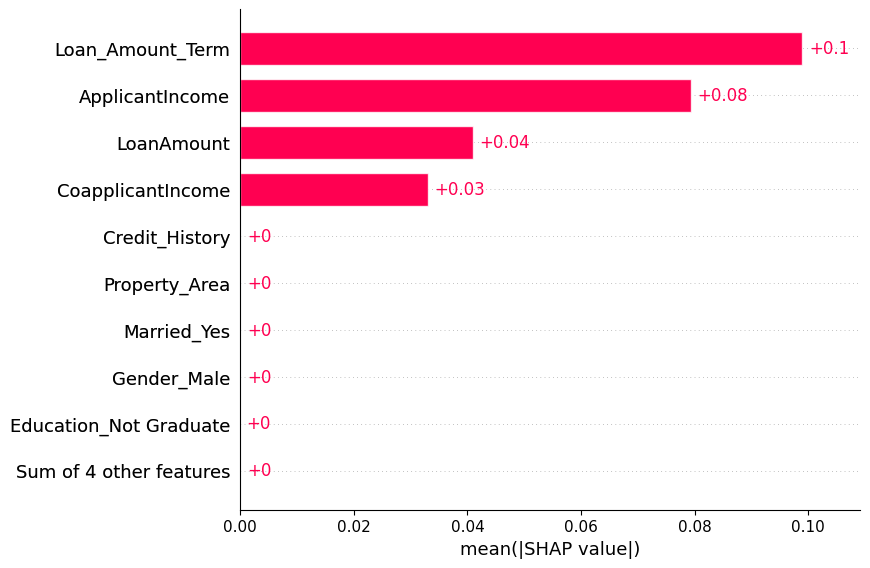

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import shap

data = pd.read_csv('/kaggle/input/datasets/burak3ergun/loan-data-set/loan_data_set.csv')

data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
data = data.dropna()

area_map = {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
data['Property_Area'] = data['Property_Area'].map(area_map)
data['Loan_Status'] = data['Loan_Status'].map({'Y': 0, 'N': 1})

X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = data['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(solver='saga', max_iter=5000)
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)